# Experiment B Analysis

This notebook reproduces the main statistical analysis for Experiment B.

# Statistical Summary

Primary hypothesis testing methods:

Experiment A:
- Binomial test
- Confidence interval
- Cohen’s h

Experiment B:
- Welch t-test
- Chi-square test
- Cramér’s V
- Cohen’s d

## Files used
- `experiment_b_data_participant_summary.csv`
- `experiment_b_data_scenario.csv`

## Main analyses
1. Group comparison: Matched vs Mismatched
2. Welch t-tests for participant-level outcomes
3. Effect sizes (Cohen's d)
4. 95% confidence intervals
5. Binary contact-again analysis
6. Persona-level summary
7. Scenario-level summary
8. Visualization export


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import math
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.multitest import multipletests

pd.options.display.float_format = '{:.4f}'.format

base = Path(".")

In [23]:
part = pd.read_csv(base / "../data/experiment_b_data_participant_summary.csv", sep=";", decimal=",", encoding="utf-8-sig")
part.columns = [c.strip() for c in part.columns]
part.head()

,Participant_ID,Group,Persona,Total_Scenarios,Mean_Ease,Mean_Helpfulness,Mean_Trust,Mean_Contact_Likert,Mean_Style_Match,Overall_Mean,Contact_Binary_Rate,Overall_Helpfulness_Global,Confidence_Global
0,P001,Matched,STJ,4,4.2500,4.7500,5.0000,5.0000,5.0000,4.8000,1.0000,5,5
1,P002,Matched,STJ,4,3.7500,3.5000,3.7500,3.0000,3.0000,3.4000,0.7500,4,4
2,P003,Matched,STJ,4,4.2500,4.0000,4.0000,4.0000,4.0000,4.0500,0.7500,4,4
3,P004,Matched,STJ,4,3.7500,3.5000,3.5000,3.2500,3.2500,3.4500,0.5000,4,4
4,P005,Matched,STJ,4,5.0000,5.0000,5.0000,5.0000,4.7500,4.9500,1.0000,3,5


In [5]:
scen = pd.read_csv(base / "../data/experiment_b_data_scenario.csv", sep=";", decimal=",", encoding="utf-8-sig")
scen.columns = [c.strip() for c in scen.columns]
scen.head()

,Participant_ID,Group,Persona,Scenario_ID,Ease,Helpfulness,Trust,Contact_Likert,Style_Match,Contact_Binary,Overall_Score_Scenario
0,P001,Matched,STJ,S1_Suspicious_Email,5,5,5,5,5,1,5.0000
1,P001,Matched,STJ,S2_Course_Schedule,4,5,5,5,5,1,4.5000
2,P001,Matched,STJ,S3_WiFi_Access,4,4,5,5,5,1,4.5000
3,P001,Matched,STJ,S4_Thesis_Topic,4,5,5,5,5,1,4.5000
4,P002,Matched,STJ,S1_Suspicious_Email,4,4,4,3,3,1,3.5000


In [25]:
# Group means
group_means = part.groupby("Group").agg(
    n=("Participant_ID", "count"),
    Mean_Ease=("Mean_Ease", "mean"),
    Mean_Helpfulness=("Mean_Helpfulness", "mean"),
    Mean_Trust=("Mean_Trust", "mean"),
    Mean_Contact_Likert=("Mean_Contact_Likert", "mean"),
    Mean_Style_Match=("Mean_Style_Match", "mean"),
    Overall_Mean=("Overall_Mean", "mean"),
    Contact_Binary_Rate=("Contact_Binary_Rate", "mean"),
    Overall_Helpfulness_Global=("Overall_Helpfulness_Global", "mean"),
    Confidence_Global=("Confidence_Global", "mean"),
).reset_index()
group_means


,Group,n,Mean_Ease,Mean_Helpfulness,Mean_Trust,Mean_Contact_Likert,Mean_Style_Match,Overall_Mean,Contact_Binary_Rate,Overall_Helpfulness_Global,Confidence_Global
0,Matched,43,4.5087,4.4680,4.4535,4.4041,4.2965,4.4262,0.8953,4.1860,4.2791
1,Mismatched,37,4.1081,4.0203,4.1351,3.9392,3.6419,3.9689,0.7770,4.0000,4.0000


In [26]:
# Group comparison tests
def cohens_d_ind(a, b):
    a = np.asarray(pd.Series(a).dropna(), dtype=float)
    b = np.asarray(pd.Series(b).dropna(), dtype=float)
    na, nb = len(a), len(b)
    sa2, sb2 = a.var(ddof=1), b.var(ddof=1)
    sp = math.sqrt(((na-1)*sa2 + (nb-1)*sb2) / (na+nb-2))
    return (a.mean() - b.mean()) / sp if sp != 0 else np.nan

ordered_groups = [g for g in ["Matched", "Mismatched"] if g in part["Group"].unique()]
g1, g2 = ordered_groups[0], ordered_groups[1]

metrics = [
    "Mean_Ease", "Mean_Helpfulness", "Mean_Trust", "Mean_Contact_Likert",
    "Mean_Style_Match", "Overall_Mean", "Contact_Binary_Rate",
    "Overall_Helpfulness_Global", "Confidence_Global"
]

rows = []
for m in metrics:
    a = part.loc[part["Group"] == g1, m]
    b = part.loc[part["Group"] == g2, m]
    t = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    d = cohens_d_ind(a, b)
    rows.append({
        "Metric": m,
        f"{g1}_Mean": a.mean(),
        f"{g2}_Mean": b.mean(),
        "Mean_Difference": a.mean() - b.mean(),
        "t_stat": t.statistic,
        "p_value": t.pvalue,
        "Cohens_d": d
    })
tests_df = pd.DataFrame(rows)
tests_df


,Metric,Matched_Mean,Mismatched_Mean,Mean_Difference,t_stat,p_value,Cohens_d
0,Mean_Ease,4.5087,4.1081,0.4006,2.6036,0.0113,0.5921
1,Mean_Helpfulness,4.4680,4.0203,0.4478,3.1944,0.0020,0.7136
2,Mean_Trust,4.4535,4.1351,0.3184,2.1079,0.0383,0.4712
3,Mean_Contact_Likert,4.4041,3.9392,0.4649,2.7530,0.0074,0.6217
4,Mean_Style_Match,4.2965,3.6419,0.6546,3.4979,0.0008,0.7972
5,Overall_Mean,4.4262,3.9689,0.4572,3.1092,0.0026,0.6976
6,Contact_Binary_Rate,0.8953,0.7770,0.1183,2.1156,0.0388,0.4925
7,Overall_Helpfulness_Global,4.1860,4.0000,0.1860,1.0339,0.3048,0.2359
8,Confidence_Global,4.2791,4.0000,0.2791,1.5397,0.1285,0.3534


In [27]:
# Mann–Whitney U Test for Matched vs Mismatched group comparisons
mw_results = []

metrics = [
    "Mean_Ease",
    "Mean_Helpfulness",
    "Mean_Trust",
    "Mean_Contact_Likert",
    "Mean_Style_Match",
    "Overall_Mean",
    "Contact_Binary_Rate",
    "Overall_Helpfulness_Global",
    "Confidence_Global"
]

for metric in metrics:
    matched_vals = part.loc[part["Group"] == "Matched", metric].dropna()
    mismatched_vals = part.loc[part["Group"] == "Mismatched", metric].dropna()

    mw_stat, mw_p = stats.mannwhitneyu(
      matched_vals,
      mismatched_vals,
      alternative="greater"
    )

    mw_results.append({
        "Metric": metric,
        "MW_Statistic": mw_stat,
        "MW_p_value": mw_p
    })

mw_df = pd.DataFrame(mw_results)

mw_df

,Metric,MW_Statistic,MW_p_value
0,Mean_Ease,1042.0000,0.0070
1,Mean_Helpfulness,1106.5000,0.0011
2,Mean_Trust,1051.5000,0.0060
3,Mean_Contact_Likert,1080.5000,0.0026
4,Mean_Style_Match,1132.0000,0.0005
5,Overall_Mean,1114.5000,0.0010
6,Contact_Binary_Rate,953.0000,0.0398
7,Overall_Helpfulness_Global,868.5000,0.2215
8,Confidence_Global,923.5000,0.0866


In [6]:
# Binary contact-again analysis
contact_yes = scen.groupby("Group")["Contact_Binary"].agg(["sum", "count", "mean"]).reset_index()
contact_yes


,Group,sum,count,mean
0,Matched,157,176,0.8920
1,Mismatched,115,148,0.7770


In [29]:
# Contingency table: Group × Contact_Binary
contact_table = pd.crosstab(scen["Group"], scen["Contact_Binary"])
contact_table

Contact_Binary,0,1
Group,,
Matched,19,157
Mismatched,33,115


In [30]:
# Chi-square test of independence
chi2, p_value, dof, expected = stats.chi2_contingency(contact_table)

chi2_df = pd.DataFrame({
    "Statistic": ["Chi2", "p_value", "df"],
    "Value": [chi2, p_value, dof]
})

chi2_df

,Statistic,Value
0,Chi2,7.0631
1,p_value,0.0079
2,df,1.0000


In [31]:
# Expected frequencies
expected_df = pd.DataFrame(
    expected,
    index=contact_table.index,
    columns=contact_table.columns
)

expected_df

Contact_Binary,0,1
Group,,
Matched,28.2469,147.7531
Mismatched,23.7531,124.2469


In [32]:
# Effect size for 2x2 chi-square: Phi coefficient
n_total = contact_table.to_numpy().sum()
phi = np.sqrt(chi2 / n_total)

phi_df = pd.DataFrame({
    "Statistic": ["Phi"],
    "Value": [phi]
})

phi_df

,Statistic,Value
0,Phi,0.1476


In [33]:
# Cramér's V effect size
cramers_v = np.sqrt(
    chi2 / (n_total * (min(contact_table.shape) - 1))
)

cramers_v_df = pd.DataFrame({
    "Statistic": ["Cramers_V"],
    "Value": [cramers_v]
})

cramers_v_df

,Statistic,Value
0,Cramers_V,0.1476


In [34]:
# Odds ratio for contact-again binary outcome
# Assumes rows = groups, columns = Contact_Binary (0/1)

table = contact_table.copy()

# Reindex explicitly for safety
row_order = ["Matched", "Missmatched"] if "Missmatched" in table.index else ["Matched", "Mismatched"]
col_order = [0, 1]

table = table.reindex(index=row_order, columns=col_order)

a = table.loc[row_order[0], 1]  # Matched, Yes
b = table.loc[row_order[0], 0]  # Matched, No
c = table.loc[row_order[1], 1]  # Mismatched, Yes
d = table.loc[row_order[1], 0]  # Mismatched, No

odds_ratio = (a * d) / (b * c)

or_df = pd.DataFrame({
    "Statistic": ["Odds_Ratio"],
    "Value": [odds_ratio]
})

or_df

,Statistic,Value
0,Odds_Ratio,2.3712


In [35]:
# Persona-level summary
persona_summary = part.groupby(["Persona", "Group"]).agg(
    n=("Participant_ID", "count"),
    Overall_Mean=("Overall_Mean", "mean"),
    Contact_Binary_Rate=("Contact_Binary_Rate", "mean"),
    Mean_Style_Match=("Mean_Style_Match", "mean"),
).reset_index()
persona_summary


,Persona,Group,n,Overall_Mean,Contact_Binary_Rate,Mean_Style_Match
0,NFJ,Matched,8,4.6500,0.8750,4.4688
1,NFJ,Mismatched,4,4.1500,0.8125,4.0625
2,NTP,Matched,7,4.3429,0.9286,4.2857
3,NTP,Mismatched,7,4.1071,0.7143,3.7143
4,SFP,Matched,9,4.6667,0.9444,4.5556
5,SFP,Mismatched,13,3.7500,0.7692,3.4615
6,STJ,Matched,19,4.2487,0.8684,4.1053
7,STJ,Mismatched,13,4.0577,0.8077,3.6538


In [36]:
# Scenario-level summary
scenario_summary = scen.groupby(["Scenario_ID", "Group"]).agg(
    n=("Participant_ID", "count"),
    Ease=("Ease", "mean"),
    Helpfulness=("Helpfulness", "mean"),
    Trust=("Trust", "mean"),
    Contact_Likert=("Contact_Likert", "mean"),
    Style_Match=("Style_Match", "mean"),
    Contact_Binary_Rate=("Contact_Binary", "mean"),
).reset_index()
scenario_summary["Overall_Score"] = scenario_summary[
    ["Ease", "Helpfulness", "Trust", "Contact_Likert", "Style_Match"]
].mean(axis=1)
scenario_summary


,Scenario_ID,Group,n,Ease,Helpfulness,Trust,Contact_Likert,Style_Match,Contact_Binary_Rate,Overall_Score
0,S1_Suspicious_Email,Matched,44,4.7500,4.7273,4.6364,4.6818,4.6591,1.0000,4.6909
1,S1_Suspicious_Email,Mismatched,37,4.2703,4.4054,4.2432,4.2432,3.7838,0.8108,4.1892
2,S2_Course_Schedule,Matched,44,4.1136,4.0455,4.1364,4.0000,3.7273,0.6818,4.0045
3,S2_Course_Schedule,Mismatched,37,4.0811,3.9730,4.1892,3.8919,3.6757,0.7568,3.9622
4,S3_WiFi_Access,Matched,44,4.6364,4.5455,4.4773,4.4091,4.3636,0.9318,4.4864
5,S3_WiFi_Access,Mismatched,37,3.8649,3.4865,3.7568,3.4324,3.2432,0.6757,3.5568
6,S4_Thesis_Topic,Matched,44,4.4773,4.5000,4.5227,4.4545,4.3864,0.9545,4.4682
7,S4_Thesis_Topic,Mismatched,37,4.2162,4.2162,4.3514,4.1892,3.8649,0.8649,4.1676


In [45]:
# Group comparison analysis (Matched vs Mismatched)
metrics = [
    "Mean_Ease",
    "Mean_Helpfulness",
    "Mean_Trust",
    "Mean_Contact_Likert",
    "Mean_Style_Match",
    "Overall_Mean",
    "Contact_Binary_Rate",
    "Overall_Helpfulness_Global",
    "Confidence_Global"
]

# Helper: Cohen's d for independent groups
def cohens_d_ind(a: pd.Series, b: pd.Series) -> float:
    a = np.asarray(a.dropna(), dtype=float)
    b = np.asarray(b.dropna(), dtype=float)

    na, nb = len(a), len(b)
    sa2 = a.var(ddof=1)
    sb2 = b.var(ddof=1)

    sp = math.sqrt(((na - 1) * sa2 + (nb - 1) * sb2) / (na + nb - 2))
    if sp == 0:
        return np.nan
    return (a.mean() - b.mean()) / sp

# Group names
g1 = "Matched"
g2 = "Mismatched"

rows = []

for metric in metrics:
    a = part.loc[part["Group"] == g1, metric]
    b = part.loc[part["Group"] == g2, metric]

    # Welch t-test
    t_res = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")

    mean_a = a.mean()
    mean_b = b.mean()
    mean_diff = mean_a - mean_b
    d = cohens_d_ind(a, b)

    # Welch-Satterthwaite confidence interval for mean difference
    na = a.dropna().shape[0]
    nb = b.dropna().shape[0]
    va = a.var(ddof=1)
    vb = b.var(ddof=1)

    se = math.sqrt((va / na) + (vb / nb))

    df = ((va / na) + (vb / nb)) ** 2 / (
        ((va / na) ** 2) / (na - 1) + ((vb / nb) ** 2) / (nb - 1)
    )

    t_crit = stats.t.ppf(0.975, df)
    ci_low = mean_diff - t_crit * se
    ci_high = mean_diff + t_crit * se

    rows.append({
        "Metric": metric,
        "Matched_Mean": mean_a,
        "Mismatched_Mean": mean_b,
        "Mean_Difference": mean_diff,
        "t_stat": t_res.statistic,
        "p_value": t_res.pvalue,
        "Cohens_d": d,
        "CI95_Low": ci_low,
        "CI95_High": ci_high
    })

group_comparison = pd.DataFrame(rows)

# Apply FDR correction to the original Welch t-test p-values
fdr_results = multipletests(
    group_comparison["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

group_comparison["p_value_FDR"] = fdr_results[1]
group_comparison["Significant_FDR"] = fdr_results[0]

# Preview
group_comparison

,Metric,Matched_Mean,Mismatched_Mean,Mean_Difference,t_stat,p_value,Cohens_d,CI95_Low,CI95_High,p_value_FDR,Significant_FDR
0,Mean_Ease,4.5087,4.1081,0.4006,2.6036,0.0113,0.5921,0.0937,0.7075,0.0203,True
1,Mean_Helpfulness,4.4680,4.0203,0.4478,3.1944,0.0020,0.7136,0.1687,0.7269,0.0079,True
2,Mean_Trust,4.4535,4.1351,0.3184,2.1079,0.0383,0.4712,0.0176,0.6191,0.0499,True
3,Mean_Contact_Likert,4.4041,3.9392,0.4649,2.7530,0.0074,0.6217,0.1284,0.8014,0.0167,True
4,Mean_Style_Match,4.2965,3.6419,0.6546,3.4979,0.0008,0.7972,0.2813,1.0280,0.0074,True
5,Overall_Mean,4.4262,3.9689,0.4572,3.1092,0.0026,0.6976,0.1644,0.7501,0.0079,True
6,Contact_Binary_Rate,0.8953,0.7770,0.1183,2.1156,0.0388,0.4925,0.0063,0.2304,0.0499,True
7,Overall_Helpfulness_Global,4.1860,4.0000,0.1860,1.0339,0.3048,0.2359,-0.1730,0.5451,0.3048,False
8,Confidence_Global,4.2791,4.0000,0.2791,1.5397,0.1285,0.3534,-0.0829,0.6411,0.1445,False


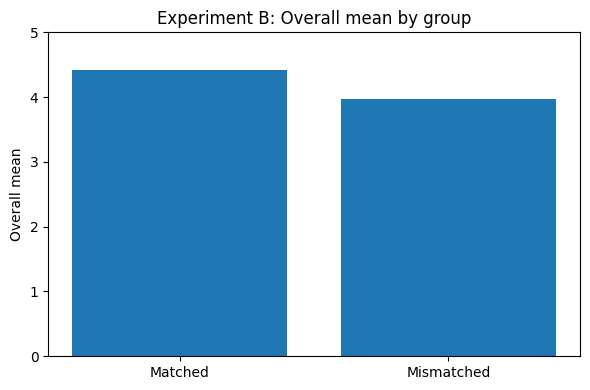

In [38]:
# Visualization 1: Group means
plt.figure(figsize=(6, 4))
plt.bar(group_means["Group"], group_means["Overall_Mean"])
plt.ylabel("Overall mean")
plt.title("Experiment B: Overall mean by group")
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

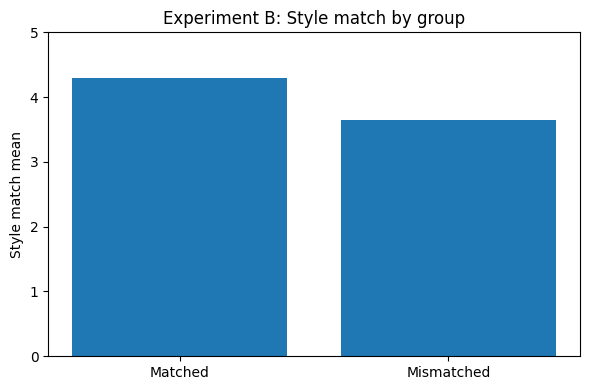

In [39]:
# Visualization 2: Style match by group
plt.figure(figsize=(6, 4))
plt.bar(group_means["Group"], group_means["Mean_Style_Match"])
plt.ylabel("Style match mean")
plt.title("Experiment B: Style match by group")
plt.ylim(0, 5)
plt.tight_layout()

plt.show()


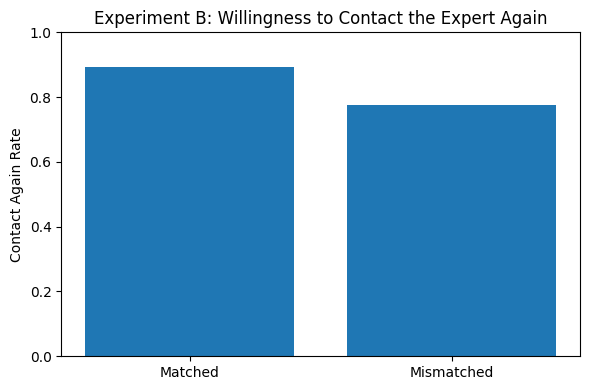

In [ ]:
# Visualization 3: Contact-again rate comparison
plt.figure(figsize=(6, 4))
plt.bar(contact_yes["Group"], contact_yes["mean"])
plt.ylabel("Contact Again Rate")
plt.title("Experiment B: Willingness to Contact the Expert Again")
plt.ylim(0, 1.0)
plt.tight_layout()

plt.show()

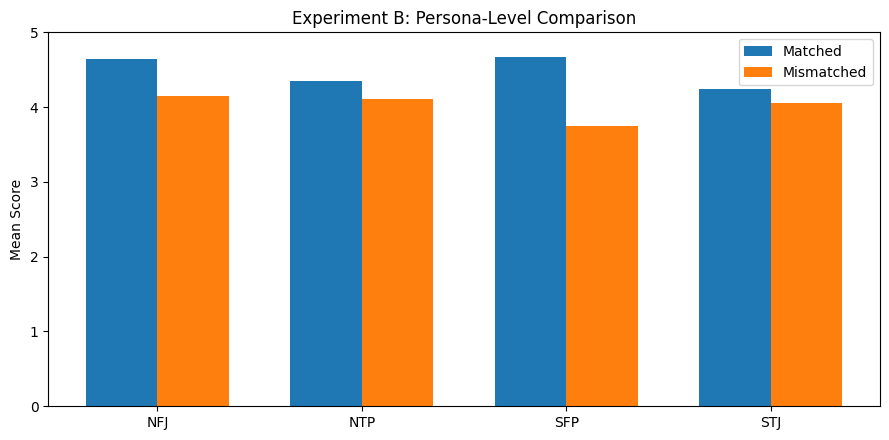

In [ ]:
# Visualization 4: Persona-level comparison
persona_pivot = persona_summary.pivot(index="Persona", columns="Group", values="Overall_Mean").fillna(np.nan)
x = np.arange(len(persona_pivot.index))
width = 0.35
plt.figure(figsize=(9, 4.5))
for i, col in enumerate(persona_pivot.columns[:2]):
    plt.bar(x + (i - 0.5) * width, persona_pivot[col], width=width, label=col)
plt.xticks(x, persona_pivot.index)
plt.ylabel("Mean Score")
plt.title("Experiment B: Persona-Level Comparison")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()

plt.show()


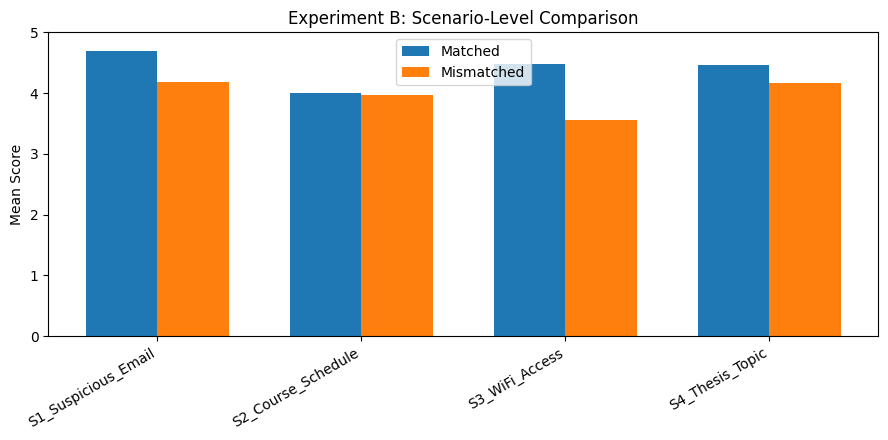

In [ ]:
# Visualization 5: Scenario-level comparison
scenario_pivot = scenario_summary.pivot(index="Scenario_ID", columns="Group", values="Overall_Score").fillna(np.nan)
x = np.arange(len(scenario_pivot.index))
width = 0.35
plt.figure(figsize=(9, 4.5))
for i, col in enumerate(scenario_pivot.columns[:2]):
    plt.bar(x + (i - 0.5) * width, scenario_pivot[col], width=width, label=col)
plt.xticks(x, scenario_pivot.index, rotation=30, ha="right")
plt.ylabel("Mean Score")
plt.title("Experiment B: Scenario-Level Comparison")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()

plt.show()


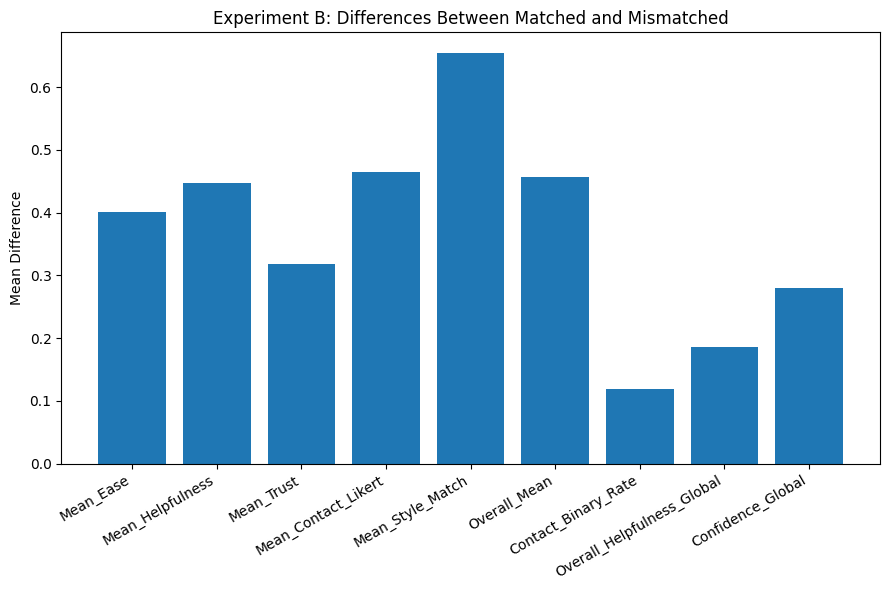

In [ ]:
# Visualization 6: Mean Differences Between Matched and Mismatched Conditions
x = np.arange(len(group_comparison.index))
plt.figure(figsize=(9, 6))
plt.bar(
  group_comparison["Metric"],
  group_comparison["Mean_Difference"]
)
plt.title("Experiment B: Differences Between Matched and Mismatched")
plt.ylabel("Mean Difference")
plt.xticks(x, group_comparison["Metric"], rotation=30, ha="right")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

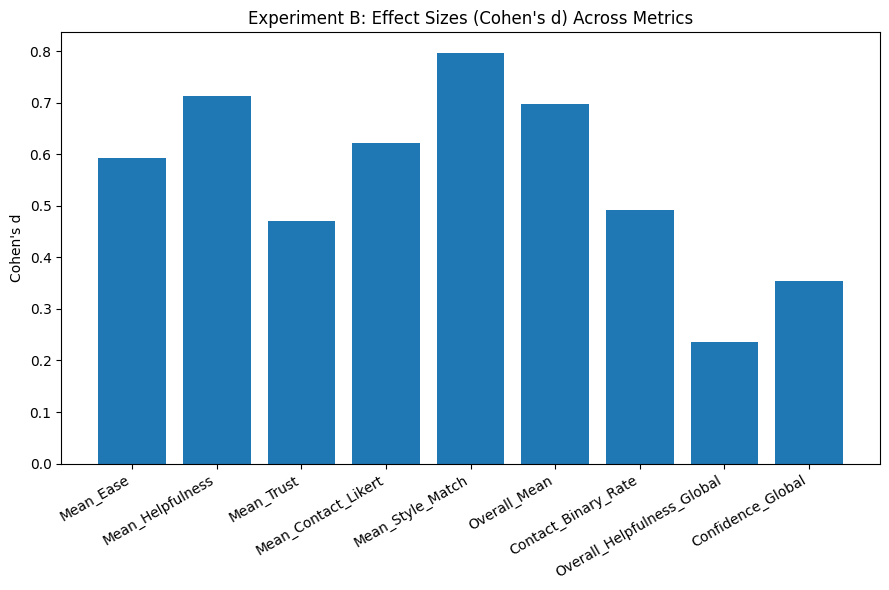

In [ ]:
# Visualization 7: Effect Sizes (Cohen's d) Across Metrics
x = np.arange(len(group_comparison.index))
plt.figure(figsize=(9, 6))
plt.bar(
  group_comparison["Metric"],
  group_comparison["Cohens_d"]
)
plt.title("Experiment B: Effect Sizes (Cohen's d) Across Metrics")
plt.ylabel("Cohen's d")
plt.xticks(x, group_comparison["Metric"], rotation=30, ha="right")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()